# PINO/FNO Surrogate — v2: Diurnal Dataset
**Sindh Research Project 321 — Stage 2 (upgraded)**

Trains and evaluates the FNO baseline and PINO surrogate on the **diurnal, periodic-day dataset** produced by `fdm_solver_diurnal.ipynb`.

**Before running**, upload to `MyDrive`: `sindh_dataset_diurnal.npz` **and** `material_ranking_diurnal.csv` (both produced by the FDM notebook).

**Changes vs. v1:** `T_END = 86400 s`; dataset filename; checkpoints saved as `*_diurnal.pt`; ranking and cost tables now **load** the FDM ground truth from the CSV (no hard-coded numbers); figure cells rewritten (unbiased median-error sample, no clipping, clock-time axes); new figures: error-vs-position, dynamic-metrics parity, worst-case sample, climate margin map, and an optional data-efficiency study. Architecture, seeds, split, and training hyperparameters are identical to v1.

In [1]:
"""
================================================================
SECTION 1 — Setup, data loading (DIURNAL dataset), normalization
================================================================
Sindh Research Project 321 — Stage 2 (v2): PINO/FNO surrogate on the
DIURNAL dataset produced by fdm_solver_diurnal.ipynb.

Changes vs. v1:
  * dataset  : sindh_dataset_diurnal.npz  (final PERIODIC day of 5)
  * T_END    : 86400 s (24 h window; was 43200 s)
  * mu[6]    : T_out_max_C  = DAILY MAXIMUM outdoor temperature [C]
  * mu[8]    : G_s_peak     = solar-noon PEAK irradiance [W/m^2]
  * extra ground-truth arrays loaded: J_peak, time_lag_h, decrement,
    periodicity_K (used by the new dynamic-metric figures)
  * forcing-model mirror (constants + profiles) so figures can
    reconstruct T_out(t), G_s(t), sol-air T_sa(t) from mu

Field shape is unchanged: (N_samples, 65, 121). Everything else in the
pipeline (channels, architecture, seeds, split) is identical to v1.

BEFORE RUNNING: upload BOTH files produced by the FDM notebook to
MyDrive:  sindh_dataset_diurnal.npz  and  material_ranking_diurnal.csv
================================================================
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(0)
torch.cuda.manual_seed(0)
np.random.seed(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ----------------------------------------------------------------
# Load dataset
# ----------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')
DRIVE = '/content/drive/MyDrive/'

data = np.load(DRIVE + 'sindh_dataset_diurnal.npz')

mu_raw     = data['mu'].astype(np.float32)        # (N, 9)
T_field    = data['T_field'].astype(np.float32)   # (N, 65, 121) [K], final day
J_peak_gt  = data['J_peak'].astype(np.float32)    # (N,) FDM ground truth [K]
lag_gt     = data['time_lag_h'].astype(np.float32)
decr_gt    = data['decrement'].astype(np.float32)
period_gt  = data['periodicity_K'].astype(np.float32)

N_samples, N_x, N_t = T_field.shape
T_END = 86400.0   # s — the saved window is the final 24-h periodic day

print(f"N_samples={N_samples}, N_x={N_x}, N_t={N_t}")
print(f"T_field range: {T_field.min():.2f} - {T_field.max():.2f} K")
print(f"periodicity check: max={period_gt.max():.3e} K "
      f"(should be << PINO error budget)")

xi  = np.linspace(0.0, 1.0, N_x, dtype=np.float32)          # (65,)
tau = (data['t_save'].astype(np.float32) / T_END)           # (121,)
assert tau[0] == 0.0 and abs(tau[-1] - 1.0) < 1e-6

PARAM_NAMES = ['k_dry', 'rho', 'cp', 'alpha_moist', 'L', 'w0',
               'T_out_max', 'T_in', 'G_s_peak']

# ----------------------------------------------------------------
# Forcing-model mirror (must match fdm_solver_diurnal.ipynb)
# ----------------------------------------------------------------
DAY_S, DAYLIGHT_S = 86400.0, 43200.0
DELTA_DIURNAL, T_PEAK_LAG_S = 12.0, 3.0*3600.0
H_OUT, ALPHA_S = 25.0, 0.7

def G_s_profile(t, G_peak):
    tau_d = np.mod(t, DAY_S)
    return np.where(tau_d < DAYLIGHT_S,
                    G_peak*np.sin(np.pi*tau_d/DAYLIGHT_S), 0.0)

def T_out_profile(t, T_out_max_C):
    A = 0.5*DELTA_DIURNAL
    tau_d = np.mod(t, DAY_S)
    return (T_out_max_C+273.15) - A + A*np.sin(2*np.pi*(tau_d-T_PEAK_LAG_S)/DAY_S)

def sol_air_profile(t, T_out_max_C, G_peak):
    return T_out_profile(t, T_out_max_C) + ALPHA_S*G_s_profile(t, G_peak)/H_OUT

# ----------------------------------------------------------------
# Train / val / test split (identical procedure and seed to v1)
# ----------------------------------------------------------------
N = N_samples
perm = np.random.permutation(N)
n_test  = int(0.10 * N)
n_val   = int(0.10 * N)
n_train = N - n_test - n_val

idx_train = perm[:n_train]
idx_val   = perm[n_train:n_train+n_val]
idx_test  = perm[n_train+n_val:]

print(f"train={len(idx_train)}  val={len(idx_val)}  test={len(idx_test)}")

# ----------------------------------------------------------------
# Normalization statistics (TRAIN split only)
# ----------------------------------------------------------------
mu_mean = mu_raw[idx_train].mean(axis=0)
mu_std  = mu_raw[idx_train].std(axis=0) + 1e-8
T_mean  = T_field[idx_train].mean()
T_std   = T_field[idx_train].std() + 1e-8

print("\nmu normalization (train):")
for name, m, s in zip(PARAM_NAMES, mu_mean, mu_std):
    print(f"  {name:<12s} mean={m:10.4f}  std={s:10.4f}")
print(f"\nT_field normalization (train): mean={T_mean:.4f} K  std={T_std:.4f} K")

norm_stats = dict(mu_mean=mu_mean, mu_std=mu_std, T_mean=T_mean, T_std=T_std)

Using device: cuda
Mounted at /content/drive
N_samples=1500, N_x=65, N_t=121
T_field range: 287.58 - 340.54 K
periodicity check: max=4.349e-02 K (should be << PINO error budget)
train=1200  val=150  test=150

mu normalization (train):
  k_dry        mean=    0.8458  std=    0.3742
  rho          mean= 1502.0303  std=  405.1731
  cp           mean= 1317.7113  std=  385.6303
  alpha_moist  mean=    0.0055  std=    0.0026
  L            mean=    0.2987  std=    0.0867
  w0           mean=   15.1059  std=    8.6006
  T_out_max    mean=   36.4808  std=    6.6477
  T_in         mean=   35.0755  std=    5.8474
  G_s_peak     mean=  548.2251  std=  202.9606

T_field normalization (train): mean=308.3723 K  std=6.1409 K


In [2]:
"""
================================================================
SECTION 2 — Dataset class and DataLoaders
================================================================
Each sample is encoded as a 2D field over (x, t) with input
channels:
  ch0: xi   (normalized space, broadcast over t)
  ch1: tau  (normalized time, broadcast over x)
  ch2..ch10: 9 normalized mu parameters, broadcast over (x,t)

Target: normalized T(x,t), shape (65, 121)
================================================================
"""

class SindhDataset(Dataset):
    def __init__(self, mu, T, xi, tau, mu_mean, mu_std, T_mean, T_std):
        self.mu  = mu                       # (N, 9) raw
        self.T   = T                        # (N, 65, 121) raw [K]
        self.xi  = xi                       # (65,)
        self.tau = tau                      # (121,)
        self.mu_mean, self.mu_std = mu_mean, mu_std
        self.T_mean, self.T_std   = T_mean, T_std

        self.Nx = len(xi)
        self.Nt = len(tau)

    def __len__(self):
        return len(self.mu)

    def __getitem__(self, idx):
        mu_n = (self.mu[idx] - self.mu_mean) / self.mu_std   # (9,)
        T_n  = (self.T[idx]  - self.T_mean)  / self.T_std    # (65,121)

        # Build input grid: (C, Nx, Nt)
        xi_grid  = np.broadcast_to(self.xi[:, None],  (self.Nx, self.Nt))   # (65,121)
        tau_grid = np.broadcast_to(self.tau[None, :], (self.Nx, self.Nt))   # (65,121)

        mu_grid = np.broadcast_to(
            mu_n[:, None, None], (9, self.Nx, self.Nt)
        )  # (9, 65, 121)

        x_in = np.concatenate([
            xi_grid[None, :, :],   # (1,65,121)
            tau_grid[None, :, :],  # (1,65,121)
            mu_grid                # (9,65,121)
        ], axis=0).astype(np.float32)   # (11, 65, 121)

        y = T_n[None, :, :].astype(np.float32)  # (1, 65, 121)

        return torch.from_numpy(x_in), torch.from_numpy(y)


train_ds = SindhDataset(mu_raw[idx_train], T_field[idx_train], xi, tau, **norm_stats)
val_ds   = SindhDataset(mu_raw[idx_val],   T_field[idx_val],   xi, tau, **norm_stats)
test_ds  = SindhDataset(mu_raw[idx_test],  T_field[idx_test],  xi, tau, **norm_stats)

BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# Quick shape check
xb, yb = next(iter(train_loader))
print(f"Input batch shape:  {xb.shape}")   # (B, 11, 65, 121)
print(f"Target batch shape: {yb.shape}")   # (B, 1, 65, 121)

Input batch shape:  torch.Size([64, 11, 65, 121])
Target batch shape: torch.Size([64, 1, 65, 121])


In [3]:
"""
================================================================
SECTION 3 — FNO2d architecture
================================================================
Standard Fourier Neural Operator (Li et al., 2021) operating
over the (x, t) grid. Input channels = 11 (xi, tau, 9 mu params,
broadcast). Output channels = 1 (normalized temperature field).

Reference implementation pattern: lifting -> stack of spectral
convolution layers with pointwise residual + GELU -> projection.
================================================================
"""

class SpectralConv2d(nn.Module):
    """2D Fourier layer: FFT -> linear transform on low modes -> inverse FFT."""
    def __init__(self, in_channels, out_channels, modes_x, modes_t):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.modes_x = modes_x
        self.modes_t = modes_t

        scale = 1.0 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            scale * torch.rand(in_channels, out_channels, modes_x, modes_t,
                                dtype=torch.cfloat)
        )
        self.weights2 = nn.Parameter(
            scale * torch.rand(in_channels, out_channels, modes_x, modes_t,
                                dtype=torch.cfloat)
        )

    def compl_mul2d(self, inp, weights):
        # inp: (B, in_c, mx, mt), weights: (in_c, out_c, mx, mt)
        return torch.einsum("bixy,ioxy->boxy", inp, weights)

    def forward(self, x):
        B, C, Nx, Nt = x.shape

        x_ft = torch.fft.rfft2(x, norm='ortho')  # (B, C, Nx, Nt//2+1), complex

        out_ft = torch.zeros(B, self.out_channels, Nx, Nt // 2 + 1,
                              dtype=torch.cfloat, device=x.device)

        mx = min(self.modes_x, Nx)
        mt = min(self.modes_t, Nt // 2 + 1)

        out_ft[:, :, :mx, :mt] = self.compl_mul2d(
            x_ft[:, :, :mx, :mt], self.weights1[:, :, :mx, :mt]
        )
        out_ft[:, :, -mx:, :mt] = self.compl_mul2d(
            x_ft[:, :, -mx:, :mt], self.weights2[:, :, :mx, :mt]
        )

        x_out = torch.fft.irfft2(out_ft, s=(Nx, Nt), norm='ortho')
        return x_out


class FNOBlock(nn.Module):
    def __init__(self, width, modes_x, modes_t):
        super().__init__()
        self.spectral = SpectralConv2d(width, width, modes_x, modes_t)
        self.linear   = nn.Conv2d(width, width, kernel_size=1)
        self.norm     = nn.BatchNorm2d(width)

    def forward(self, x):
        x1 = self.spectral(x)
        x2 = self.linear(x)
        out = self.norm(x1 + x2)
        return F.gelu(out)


class FNO2d(nn.Module):
    def __init__(self, in_channels=11, out_channels=1,
                 width=32, modes_x=12, modes_t=16, n_layers=4):
        super().__init__()
        self.lift = nn.Conv2d(in_channels, width, kernel_size=1)

        self.blocks = nn.ModuleList([
            FNOBlock(width, modes_x, modes_t) for _ in range(n_layers)
        ])

        self.project = nn.Sequential(
            nn.Conv2d(width, width * 2, kernel_size=1),
            nn.GELU(),
            nn.Conv2d(width * 2, out_channels, kernel_size=1),
        )

    def forward(self, x):
        # x: (B, in_channels, Nx, Nt)
        x = self.lift(x)
        for block in self.blocks:
            x = block(x)
        x = self.project(x)
        return x  # (B, out_channels, Nx, Nt)


# Instantiate model
model = FNO2d(
    in_channels=11, out_channels=1,
    width=32, modes_x=16, modes_t=20, n_layers=4
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"FNO2d parameters: {n_params:,}")

# Sanity forward pass
with torch.no_grad():
    test_out = model(xb.to(device))
    print(f"Output shape: {test_out.shape}")  # expect (B, 1, 65, 121)

FNO2d parameters: 2,628,481
Output shape: torch.Size([64, 1, 65, 121])


In [4]:
"""
================================================================
SECTION 4 — PDE residual loss (the "PI" in PINO)
================================================================
Governing equation (eq:heat, unchanged — solar load enters
through the BC, so the interior PDE has no forcing term):
    rho * cp * dT/dt = k_eff * d2T/dx2

with k_eff = k_dry + alpha_moist * w0  (constant per sample,
since w0 is spatially uniform and time-invariant in Path A).

Derivatives are computed in PHYSICAL units via the chain rule
from the normalized (xi, tau) grid:
    x   = xi * L           =>  d/dx   = (1/L)   * d/dxi
    t   = tau * T_END       =>  d/dt   = (1/T_END) * d/dtau

T_pred is in NORMALIZED units (T_n = (T - T_mean)/T_std), so:
    T = T_n * T_std + T_mean
    dT/dt  = T_std * dT_n/dt
    d2T/dx2 = T_std * d2T_n/dx2

Spatial/temporal derivatives of T_n are computed with finite
differences on the (uniform) xi, tau grids -- this is cheap and
avoids autograd-through-FFT issues with SpectralConv2d.

v2 note: the saved window is the final PERIODIC day, so there is no
steep start-up transient in the data; the finite-difference residual
floor of the exact FDM fields drops from ~9e-2 (v1) to ~3e-3, so a
larger lambda_T may now pay off (re-check {0.001, 0.01, 0.1}).
================================================================
"""

def pde_residual_loss(T_pred_n, mu_batch, xi, tau, T_mean, T_std,
                       mu_mean, mu_std, T_END=86400.0):
    """
    T_pred_n : (B, 1, Nx, Nt) normalized predicted temperature
    mu_batch : (B, 9) RAW (unnormalized) mu for this batch
    xi, tau  : (Nx,), (Nt,) normalized coordinate arrays (torch tensors)
    Returns scalar residual loss (mean squared PDE residual, K/s units^2...
    actually non-dimensionalized -- see normalization below).
    """
    B, _, Nx, Nt = T_pred_n.shape
    device = T_pred_n.device

    T_n = T_pred_n[:, 0, :, :]  # (B, Nx, Nt)

    dxi  = (xi[1]  - xi[0]).item()
    dtau = (tau[1] - tau[0]).item()

    # --- d T_n / d tau  (central differences, one-sided at boundaries) ---
    dTn_dtau = torch.zeros_like(T_n)
    dTn_dtau[:, :, 1:-1] = (T_n[:, :, 2:] - T_n[:, :, :-2]) / (2 * dtau)
    dTn_dtau[:, :, 0]    = (T_n[:, :, 1]  - T_n[:, :, 0])   / dtau
    dTn_dtau[:, :, -1]   = (T_n[:, :, -1] - T_n[:, :, -2])  / dtau

    # --- d2 T_n / d xi^2  (central differences, one-sided at boundaries) ---
    d2Tn_dxi2 = torch.zeros_like(T_n)
    d2Tn_dxi2[:, 1:-1, :] = (T_n[:, 2:, :] - 2*T_n[:, 1:-1, :] + T_n[:, :-2, :]) / dxi**2
    # one-sided 2nd derivative at boundaries (not used in residual since
    # boundary rows are governed by Robin BCs, not the PDE -- excluded below)
    d2Tn_dxi2[:, 0, :]  = d2Tn_dxi2[:, 1, :]
    d2Tn_dxi2[:, -1, :] = d2Tn_dxi2[:, -2, :]

    # --- physical-unit derivatives ---
    # dT/dt   = T_std/T_END * dTn/dtau
    # d2T/dx2 = T_std/L^2   * d2Tn/dxi2     (L varies per sample!)
    k_dry = mu_batch[:, 0]   # (B,)
    rho   = mu_batch[:, 1]
    cp    = mu_batch[:, 2]
    alpha_moist = mu_batch[:, 3]
    L     = mu_batch[:, 4]
    w0    = mu_batch[:, 5]

    k_eff = k_dry + alpha_moist * w0   # (B,)

    dT_dt   = (T_std / T_END) * dTn_dtau                                   # (B,Nx,Nt)
    d2T_dx2 = (T_std / (L**2)).view(B, 1, 1) * d2Tn_dxi2                   # (B,Nx,Nt)

    lhs = rho.view(B,1,1) * cp.view(B,1,1) * dT_dt
    rhs = k_eff.view(B,1,1) * d2T_dx2

    residual = lhs - rhs   # (B, Nx, Nt), units W/m^3

    # Exclude boundary rows (i=0, i=Nx-1) -- governed by Robin BCs, not the
    # interior PDE; and exclude t=0 row (IC, not a dynamics constraint).
    residual_interior = residual[:, 1:-1, 1:]

    # Non-dimensionalize residual by a characteristic scale to keep loss
    # magnitudes reasonable: rho*cp*T_std/T_END is the characteristic
    # magnitude of the LHS term.
    char_scale = (rho * cp * T_std / T_END).view(B, 1, 1)
    residual_nd = residual_interior / (char_scale + 1e-8)

    return torch.mean(residual_nd**2)

In [5]:
"""
================================================================
SECTION 5 — Training loop
================================================================
Trains two models on the same dataset/splits for fair comparison:
  1. FNO  (data-only):       L = L_data
  2. PINO (data + physics):  L = L_data + lambda_pde * L_pde

L_data = relative L2 on normalized T field (interior + boundary + IC,
i.e. the full (Nx,Nt) grid -- this is the supervised signal).
Follows Li et al. (2021) LpLoss convention.
L_pde  = PDE residual loss (Section 4), interior points only.

Both models share the same FNO2d architecture (Section 3); only
the loss function differs.
================================================================
"""

import time
import copy

xi_t  = torch.from_numpy(xi).to(device)
tau_t = torch.from_numpy(tau).to(device)


def train_model(model, train_loader, val_loader, use_pde_loss,
                 n_epochs=100, lr=1e-3, lambda_pde=0.1,
                 mu_mean=mu_mean, mu_std=mu_std, T_mean=T_mean, T_std=T_std,
                 patience=30, tag="model"):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6)

    best_val = float('inf')
    best_state = None
    patience_ctr = 0

    history = {'train_loss': [], 'val_loss': [], 'train_data': [], 'train_pde': []}

    for epoch in range(n_epochs):
        # ---- train ----
        model.train()
        ep_loss, ep_data, ep_pde = 0.0, 0.0, 0.0
        n_batches = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            # recover raw mu from the broadcast input channels 2..10
            # (channels 2..10 are normalized mu broadcast over the grid;
            #  take any single (x,t) pixel, e.g. [0,0], and de-normalize)
            mu_n_batch = xb[:, 2:11, 0, 0]               # (B, 9) normalized
            mu_batch_raw = mu_n_batch * torch.from_numpy(mu_std).to(device) \
                           + torch.from_numpy(mu_mean).to(device)

            pred = model(xb)
            # Relative L2 loss — matches Li et al. (2021) LpLoss convention
            diff = pred - yb
            loss_data = (torch.norm(diff.view(diff.shape[0], -1), dim=1) /
                         (torch.norm(yb.view(yb.shape[0], -1), dim=1) + 1e-8)).mean()

            if use_pde_loss:
                loss_pde = pde_residual_loss(
                    pred, mu_batch_raw, xi_t, tau_t, T_mean, T_std, mu_mean, mu_std
                )
                loss = loss_data + lambda_pde * loss_pde
            else:
                loss_pde = torch.tensor(0.0)
                loss = loss_data

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            ep_loss += loss.item()
            ep_data += loss_data.item()
            ep_pde  += loss_pde.item() if use_pde_loss else 0.0
            n_batches += 1

        ep_loss /= n_batches
        ep_data /= n_batches
        ep_pde  /= n_batches

        # ---- validation ----
        model.eval()
        val_loss = 0.0
        n_val_batches = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                diff = pred - yb
                val_loss += ((torch.norm(diff.view(diff.shape[0], -1), dim=1) /
                              (torch.norm(yb.view(yb.shape[0], -1), dim=1) + 1e-8)).mean()).item()
                n_val_batches += 1
        val_loss /= n_val_batches

        scheduler.step(val_loss)

        history['train_loss'].append(ep_loss)
        history['train_data'].append(ep_data)
        history['train_pde'].append(ep_pde)
        history['val_loss'].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1

        if epoch % 5 == 0 or epoch == n_epochs - 1:
            print(f"[{tag}] epoch {epoch:3d}  train={ep_loss:.4e} "
                  f"(data={ep_data:.4e}, pde={ep_pde:.4e})  val={val_loss:.4e}  "
                  f"best_val={best_val:.4e}")

        if patience_ctr >= patience:
            print(f"[{tag}] early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return model, history


# ----------------------------------------------------------------
# Train FNO baseline (data-only)
# ----------------------------------------------------------------
print("="*60)
print("Training FNO baseline (data-only)")
print("="*60)

torch.manual_seed(42)
np.random.seed(42)
model_fno = FNO2d(in_channels=11, out_channels=1, width=32,
                   modes_x=16, modes_t=20, n_layers=4).to(device)

t0 = time.time()
model_fno, hist_fno = train_model(
    model_fno, train_loader, val_loader,
    use_pde_loss=False, n_epochs=300, lr=1e-3, tag="FNO"
)
print(f"FNO training time: {time.time()-t0:.1f}s")

model_config = {'in_channels': 11, 'out_channels': 1,
                 'width': 32, 'modes_x': 16, 'modes_t': 20, 'n_layers': 4}

torch.save({
    'fno_state_dict': model_fno.state_dict(),
    'model_config':   model_config,
    'history':        hist_fno,
}, DRIVE + 'fno_model_diurnal.pt')


# ----------------------------------------------------------------
# Train PINO (data + PDE residual)
# NOTE: lambda_pde=0.01 was selected on the v1 dataset. The residual
# floor is ~30x lower on the periodic-day dataset, so if time allows,
# re-run the pilot grid lambda_pde in {0.001, 0.01, 0.1} and keep the
# best validation loss.
# ----------------------------------------------------------------
print("\n" + "="*60)
print("Training PINO (data + PDE residual)")
print("="*60)

torch.manual_seed(42)
np.random.seed(42)
model_pino = FNO2d(in_channels=11, out_channels=1, width=32,
                    modes_x=16, modes_t=20, n_layers=4).to(device)

t0 = time.time()
model_pino, hist_pino = train_model(
    model_pino, train_loader, val_loader,
    use_pde_loss=True, n_epochs=300, lr=1e-3, lambda_pde=0.01, tag="PINO"
)
print(f"PINO training time: {time.time()-t0:.1f}s")

# SAVE MODEL
torch.save({
    'pino_state_dict': model_pino.state_dict(),
    'model_config':    model_config,
    'history':         hist_pino,
}, DRIVE + 'pino_model_diurnal.pt')

print("Saved to Drive ✓")

Training FNO baseline (data-only)
[FNO] epoch   0  train=7.9469e-01 (data=7.9469e-01, pde=0.0000e+00)  val=8.7403e-01  best_val=8.7403e-01
[FNO] epoch   5  train=1.8265e-01 (data=1.8265e-01, pde=0.0000e+00)  val=1.1777e-01  best_val=1.1288e-01
[FNO] epoch  10  train=1.4286e-01 (data=1.4286e-01, pde=0.0000e+00)  val=1.0018e-01  best_val=8.4614e-02
[FNO] epoch  15  train=1.4468e-01 (data=1.4468e-01, pde=0.0000e+00)  val=1.0126e-01  best_val=7.0040e-02
[FNO] epoch  20  train=1.4903e-01 (data=1.4903e-01, pde=0.0000e+00)  val=7.2887e-02  best_val=7.0040e-02
[FNO] epoch  25  train=1.4173e-01 (data=1.4173e-01, pde=0.0000e+00)  val=5.4541e-02  best_val=5.4541e-02
[FNO] epoch  30  train=1.2926e-01 (data=1.2926e-01, pde=0.0000e+00)  val=7.2595e-02  best_val=4.9066e-02
[FNO] epoch  35  train=1.6036e-01 (data=1.6036e-01, pde=0.0000e+00)  val=8.6505e-02  best_val=4.9066e-02
[FNO] epoch  40  train=1.4331e-01 (data=1.4331e-01, pde=0.0000e+00)  val=6.0416e-02  best_val=4.9066e-02
[FNO] epoch  45  trai

In [6]:
"""
================================================================
SECTION 6 — Load saved checkpoints (FNO + PINO)
================================================================
Restores model_fno, model_pino, hist_fno, hist_pino from Drive.
Run after Cells 1-4 -- enables Sections 7-9 without retraining.
================================================================
"""
ckpt_fno = torch.load(DRIVE + 'fno_model_diurnal.pt', map_location='cpu', weights_only=False)
model_fno = FNO2d(**ckpt_fno['model_config'])
model_fno.load_state_dict(ckpt_fno['fno_state_dict'])
model_fno.to(device)
model_fno.eval()
hist_fno = ckpt_fno['history']

ckpt_pino = torch.load(DRIVE + 'pino_model_diurnal.pt', map_location='cpu', weights_only=False)
model_pino = FNO2d(**ckpt_pino['model_config'])
model_pino.load_state_dict(ckpt_pino['pino_state_dict'])
model_pino.to(device)
model_pino.eval()
hist_pino = ckpt_pino['history']

print('Models and histories successfully loaded')

Models and histories successfully loaded


In [7]:
"""
================================================================
SECTION 7 — Evaluation on test set (fills Table tab:pino_acc)
================================================================
Metrics, per the LaTeX document:
  - Relative L2 error on T (full field)
  - Mean absolute error (MAE) on QoI J = max_t T(L,t) — the PEAK
    inner-surface temperature over the final periodic day [K]
================================================================
"""

def evaluate_model(model, loader, T_mean, T_std):
    model.eval()
    rel_l2_errs = []
    J_pred_all, J_true_all = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)

            # de-normalize
            T_pred = pred[:, 0, :, :] * T_std + T_mean   # (B,Nx,Nt)
            T_true = yb[:, 0, :, :]   * T_std + T_mean

            # relative L2 error per sample
            num = torch.sqrt(torch.sum((T_pred - T_true)**2, dim=(1,2)))
            den = torch.sqrt(torch.sum(T_true**2, dim=(1,2))) + 1e-8
            rel_l2 = (num / den).cpu().numpy()
            rel_l2_errs.extend(rel_l2.tolist())

            # QoI: J(mu) = max_t T(x=L, t) -- peak inner surface temp (eq:qoi_peak)
            J_pred = T_pred[:, -1, :].max(dim=-1).values.cpu().numpy()
            J_true = T_true[:, -1, :].max(dim=-1).values.cpu().numpy()
            J_pred_all.extend(J_pred.tolist())
            J_true_all.extend(J_true.tolist())

    rel_l2_errs = np.array(rel_l2_errs)
    J_pred_all  = np.array(J_pred_all)
    J_true_all  = np.array(J_true_all)

    mean_rel_l2 = rel_l2_errs.mean()
    mae_J = np.mean(np.abs(J_pred_all - J_true_all))

    return mean_rel_l2, mae_J, rel_l2_errs, J_pred_all, J_true_all


print("="*60)
print("TEST SET EVALUATION")
print("="*60)

rel_l2_fno, mae_J_fno, _, Jp_fno, Jt_fno = evaluate_model(model_fno, test_loader, T_mean, T_std)
rel_l2_pino, mae_J_pino, _, Jp_pino, Jt_pino = evaluate_model(model_pino, test_loader, T_mean, T_std)

print(f"\n{'Model':<20s} {'Rel. L2 on T':>15s} {'MAE on J (K)':>15s}")
print("-"*52)
print(f"{'FNO (data only)':<20s} {rel_l2_fno:>15.4e} {mae_J_fno:>15.4f}")
print(f"{'PINO (ours)':<20s} {rel_l2_pino:>15.4e} {mae_J_pino:>15.4f}")

# ----------------------------------------------------------------
# LaTeX table snippet (printed for convenience)
# ----------------------------------------------------------------
print("\nLaTeX snippet for Table tab:pino_acc:\n")
print(r"FNO (data only) & " f"{rel_l2_fno:.2e}" r" & " f"{mae_J_fno:.3f}" r" \\")
print(r"PINO (ours)     & " f"{rel_l2_pino:.2e}" r" & " f"{mae_J_pino:.3f}" r" \\")

TEST SET EVALUATION

Model                   Rel. L2 on T    MAE on J (K)
----------------------------------------------------
FNO (data only)           5.4225e-04          0.2050
PINO (ours)               5.1435e-04          0.2007

LaTeX snippet for Table tab:pino_acc:

FNO (data only) & 5.42e-04 & 0.205 \\
PINO (ours)     & 5.14e-04 & 0.201 \\


## Figures
Section 8 shows the **median-PINO-error** test sample (index printed) — an unbiased choice — with no clipping of predictions, plus a **worst-case** sample as a transparency/appendix figure. Sections 8b–8c add the two cheap, high-value figures: error-vs-position (substantiates the inner-surface claim across the whole test set) and dynamic-metrics parity (shows the surrogate reproduces time lag and decrement factor, not just the scalar peak).

Median-error test sample : idx=28  (PINO J error = 0.153 K)
Worst-case test sample   : idx=128 (PINO J error = 1.759 K)


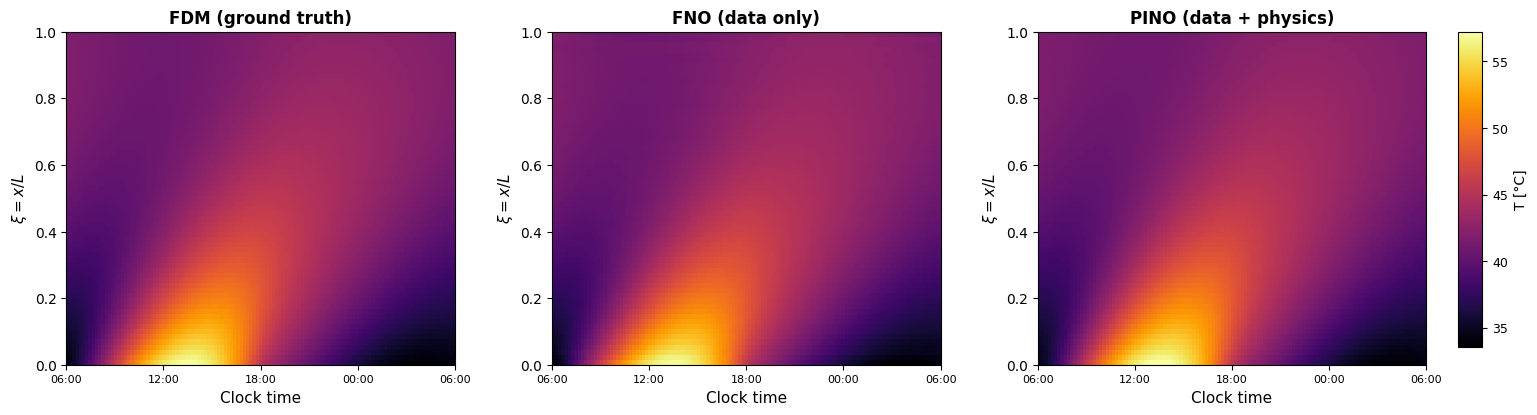

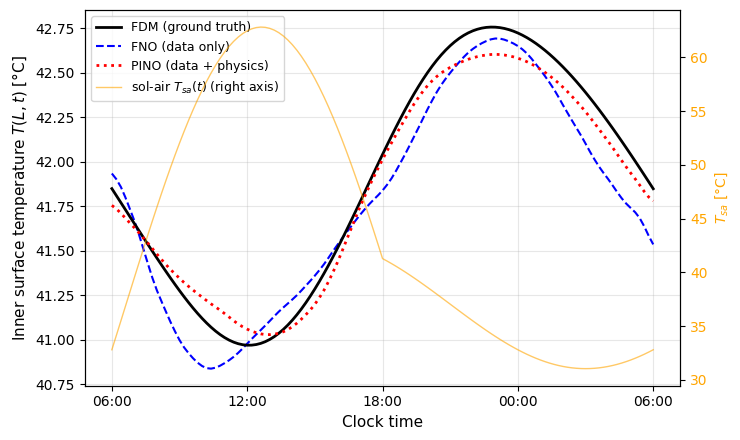

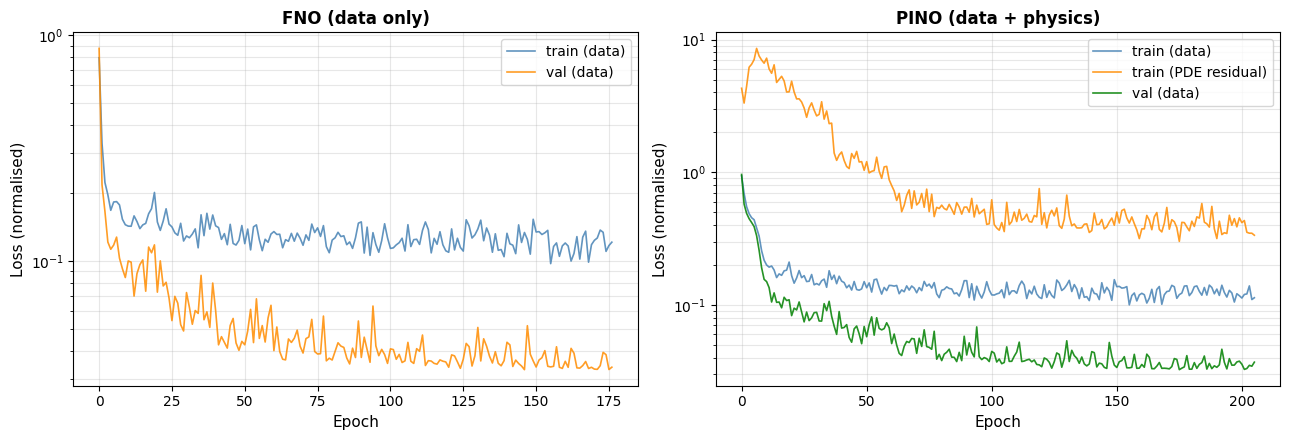

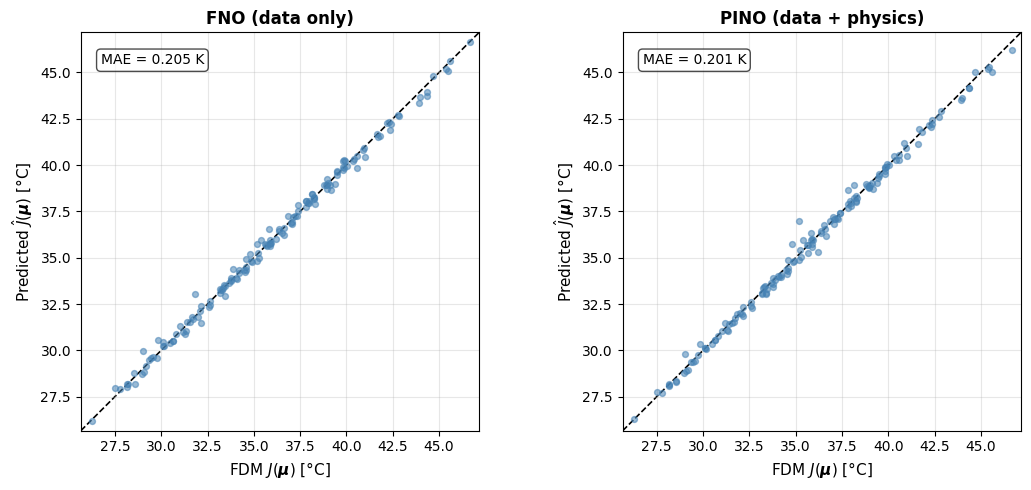

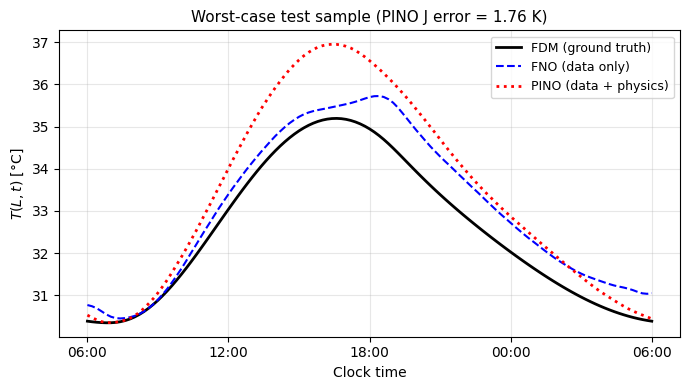


Saved: pino_field_comparison.png, pino_qoi_comparison.png,
       pino_training_curves.png, pino_parity_J.png, pino_qoi_worst_case.png


In [8]:
"""
================================================================
SECTION 8 — Visualization: PINO vs. FDM ground truth (v2)
================================================================
Changes vs. v1 (addresses code-review items):
  * UNBIASED sample selection — the shown sample is the MEDIAN-error
    test sample for PINO (not cherry-picked for accuracy), and its
    index is printed for full transparency.
  * NO clipping of predictions — fields are shown as predicted.
  * 24-h clock-time axes (final periodic day, sunrise 06:00).
  * Fig. 2 adds the sol-air forcing on a twin axis for context.
  * EXTRA appendix figure: WORST-case test sample (transparency).
Produces: pino_field_comparison.png, pino_qoi_comparison.png,
          pino_training_curves.png, pino_parity_J.png,
          pino_qoi_worst_case.png
================================================================
"""
import matplotlib.ticker as ticker

model_pino.eval(); model_fno.eval()

# ---- per-sample PINO J-errors over the test set ----
J_err = []
with torch.no_grad():
    for idx in range(len(test_ds)):
        xb_t, yb_t = test_ds[idx]
        T_true_i = yb_t[0].numpy() * T_std + T_mean
        pred_i = model_pino(xb_t.unsqueeze(0).to(device))[0, 0].cpu().numpy() * T_std + T_mean
        J_err.append(abs(pred_i[-1, :].max() - T_true_i[-1, :].max()))
J_err = np.array(J_err)

order        = np.argsort(J_err)
sample_med   = int(order[len(order)//2])       # median-error sample (main figs)
sample_worst = int(order[-1])                  # worst-case sample (appendix fig)
print(f"Median-error test sample : idx={sample_med}  "
      f"(PINO J error = {J_err[sample_med]:.3f} K)")
print(f"Worst-case test sample   : idx={sample_worst} "
      f"(PINO J error = {J_err[sample_worst]:.3f} K)")

def get_fields(idx):
    xb_t, yb_t = test_ds[idx]
    with torch.no_grad():
        p_fno  = model_fno(xb_t.unsqueeze(0).to(device))[0, 0].cpu().numpy() * T_std + T_mean
        p_pino = model_pino(xb_t.unsqueeze(0).to(device))[0, 0].cpu().numpy() * T_std + T_mean
    T_true = yb_t[0].numpy() * T_std + T_mean
    mu_i = test_ds.mu[idx]
    return T_true - 273.15, p_fno - 273.15, p_pino - 273.15, mu_i

T_true_C, pred_fno_C, pred_pino_C, mu_sel = get_fields(sample_med)
hours = 6 + tau * T_END / 3600.0          # clock time [h], 6..30

CLOCK_TICKS  = [6, 12, 18, 24, 30]
CLOCK_LABELS = ['06:00', '12:00', '18:00', '00:00', '06:00']

# ----------------------------------------------------------------
# 1. Temperature field comparison T(xi, t) — NO clipping
# ----------------------------------------------------------------
all_fields = np.stack([T_true_C, pred_fno_C, pred_pino_C])
vmin, vmax = all_fields.min(), all_fields.max()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, field, title in zip(
        axes, [T_true_C, pred_fno_C, pred_pino_C],
        ['FDM (ground truth)', 'FNO (data only)', 'PINO (data + physics)']):
    im = ax.imshow(field, aspect='auto', origin='lower',
                   extent=[6, 30, 0, 1], vmin=vmin, vmax=vmax, cmap='inferno')
    ax.set_xticks(CLOCK_TICKS); ax.set_xticklabels(CLOCK_LABELS, fontsize=8)
    ax.set_xlabel('Clock time', fontsize=11)
    ax.set_ylabel(r'$\xi = x/L$', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
fig.subplots_adjust(left=0.05, right=0.90, wspace=0.25, top=0.85)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label='T [°C]').ax.tick_params(labelsize=9)
plt.savefig('pino_field_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------
# 2. QoI time series with sol-air forcing context
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(hours, T_true_C[-1, :],   'k-',  lw=2.0, label='FDM (ground truth)', zorder=3)
ax.plot(hours, pred_fno_C[-1, :], 'b--', lw=1.5, label='FNO (data only)',    zorder=2)
ax.plot(hours, pred_pino_C[-1, :],'r:',  lw=2.0, label='PINO (data + physics)', zorder=4)
ax.set_xlabel('Clock time', fontsize=11)
ax.set_ylabel(r'Inner surface temperature $T(L,t)$ [°C]', fontsize=11)
ax.set_xticks(CLOCK_TICKS); ax.set_xticklabels(CLOCK_LABELS)
ax.grid(alpha=0.3)

ax2 = ax.twinx()
t_sec = tau * T_END
T_sa_C = sol_air_profile(t_sec, mu_sel[6], mu_sel[8]) - 273.15
ax2.plot(hours, T_sa_C, color='orange', ls='-', lw=1.0, alpha=0.6,
         label=r'sol-air $T_{sa}(t)$ (right axis)')
ax2.set_ylabel(r'$T_{sa}$ [°C]', color='orange', fontsize=10)
ax2.tick_params(axis='y', labelcolor='orange')

h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('pino_qoi_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------
# 3. Training curves (unchanged layout)
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].semilogy(hist_fno['train_loss'], color='steelblue', lw=1.2, label='train (data)', alpha=0.85)
axes[0].semilogy(hist_fno['val_loss'],   color='darkorange', lw=1.2, label='val (data)', alpha=0.85)
axes[0].set_title('FNO (data only)', fontsize=12, fontweight='bold')
axes[1].semilogy(hist_pino['train_data'], color='steelblue', lw=1.2, label='train (data)', alpha=0.85)
axes[1].semilogy(hist_pino['train_pde'],  color='darkorange', lw=1.2, label='train (PDE residual)', alpha=0.85)
axes[1].semilogy(hist_pino['val_loss'],   color='green', lw=1.2, label='val (data)', alpha=0.85)
axes[1].set_title('PINO (data + physics)', fontsize=12, fontweight='bold')
for ax in axes:
    ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel('Loss (normalised)', fontsize=11)
    ax.legend(fontsize=10); ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('pino_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------
# 4. Parity plots for J (test set) — unchanged layout
# ----------------------------------------------------------------
Jt_fno_C, Jp_fno_C  = Jt_fno - 273.15, Jp_fno - 273.15
Jt_pino_C, Jp_pino_C = Jt_pino - 273.15, Jp_pino - 273.15

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
all_J = np.concatenate([Jt_fno_C, Jp_fno_C, Jt_pino_C, Jp_pino_C])
lims = [all_J.min() - 0.5, all_J.max() + 0.5]
for ax, Jp_C, Jt_C, title, mae in zip(
        axes, [Jp_fno_C, Jp_pino_C], [Jt_fno_C, Jt_pino_C],
        ['FNO (data only)', 'PINO (data + physics)'], [mae_J_fno, mae_J_pino]):
    ax.scatter(Jt_C, Jp_C, alpha=0.55, s=18, color='steelblue', zorder=2)
    ax.plot(lims, lims, 'k--', lw=1.2, zorder=1)
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')
    ax.set_xlabel(r'FDM $J(\boldsymbol{\mu})$ [°C]', fontsize=11)
    ax.set_ylabel(r'Predicted $\hat{J}(\boldsymbol{\mu})$ [°C]', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.text(0.05, 0.92, f'MAE = {mae:.3f} K', transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
plt.tight_layout()
plt.savefig('pino_parity_J.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------
# 5. APPENDIX — worst-case test sample (transparency figure)
# ----------------------------------------------------------------
T_true_w, pred_fno_w, pred_pino_w, _ = get_fields(sample_worst)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hours, T_true_w[-1, :],   'k-',  lw=2.0, label='FDM (ground truth)')
ax.plot(hours, pred_fno_w[-1, :], 'b--', lw=1.5, label='FNO (data only)')
ax.plot(hours, pred_pino_w[-1, :],'r:',  lw=2.0, label='PINO (data + physics)')
ax.set_xticks(CLOCK_TICKS); ax.set_xticklabels(CLOCK_LABELS)
ax.set_xlabel('Clock time'); ax.set_ylabel(r'$T(L,t)$ [°C]')
ax.set_title(f'Worst-case test sample (PINO J error = {J_err[sample_worst]:.2f} K)',
             fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pino_qoi_worst_case.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: pino_field_comparison.png, pino_qoi_comparison.png,")
print("       pino_training_curves.png, pino_parity_J.png, pino_qoi_worst_case.png")


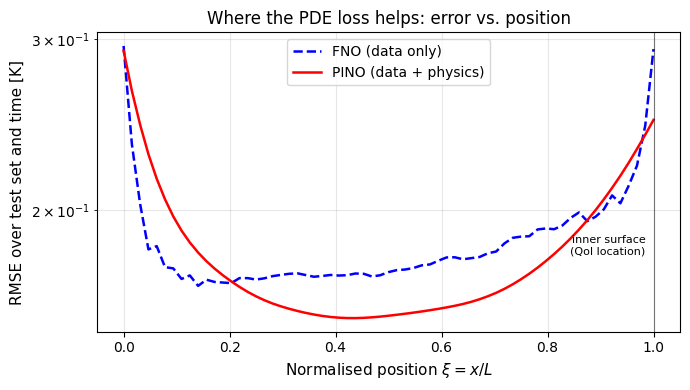

Inner-surface RMSE: FNO=0.2932 K, PINO=0.2478 K (15.5% reduction at xi=1)
Saved: pino_error_vs_position.png


In [9]:
"""
================================================================
SECTION 8b — NEW FIGURE: error vs. position (FNO vs PINO)
================================================================
Substantiates the manuscript claim that the PDE residual loss
preferentially improves accuracy near the inner surface xi = 1 —
previously asserted from one sample, now shown across the FULL
test set. Produces: pino_error_vs_position.png
================================================================
"""
def error_profile(model):
    model.eval()
    sq_sum = np.zeros(N_x); n_acc = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            err = (pred - yb)[:, 0, :, :] * T_std        # (B, Nx, Nt) in K
            sq_sum += (err**2).mean(dim=2).sum(dim=0).cpu().numpy()
            n_acc  += err.shape[0]
    return np.sqrt(sq_sum / n_acc)                       # RMSE(xi) in K

rmse_fno  = error_profile(model_fno)
rmse_pino = error_profile(model_pino)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(xi, rmse_fno,  'b--', lw=1.8, label='FNO (data only)')
ax.semilogy(xi, rmse_pino, 'r-',  lw=1.8, label='PINO (data + physics)')
ax.axvline(1.0, color='k', lw=0.8, alpha=0.5)
ax.text(0.985, ax.get_ylim()[0]*1.2, 'inner surface\n(QoI location)',
        ha='right', fontsize=8)
ax.set_xlabel(r'Normalised position $\xi = x/L$', fontsize=11)
ax.set_ylabel('RMSE over test set and time [K]', fontsize=11)
ax.set_title('Where the PDE loss helps: error vs. position', fontsize=12)
ax.legend(fontsize=10); ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('pino_error_vs_position.png', dpi=300, bbox_inches='tight')
plt.show()

gain = 100 * (1 - rmse_pino[-1] / rmse_fno[-1])
print(f"Inner-surface RMSE: FNO={rmse_fno[-1]:.4f} K, PINO={rmse_pino[-1]:.4f} K "
      f"({gain:.1f}% reduction at xi=1)")
print("Saved: pino_error_vs_position.png")

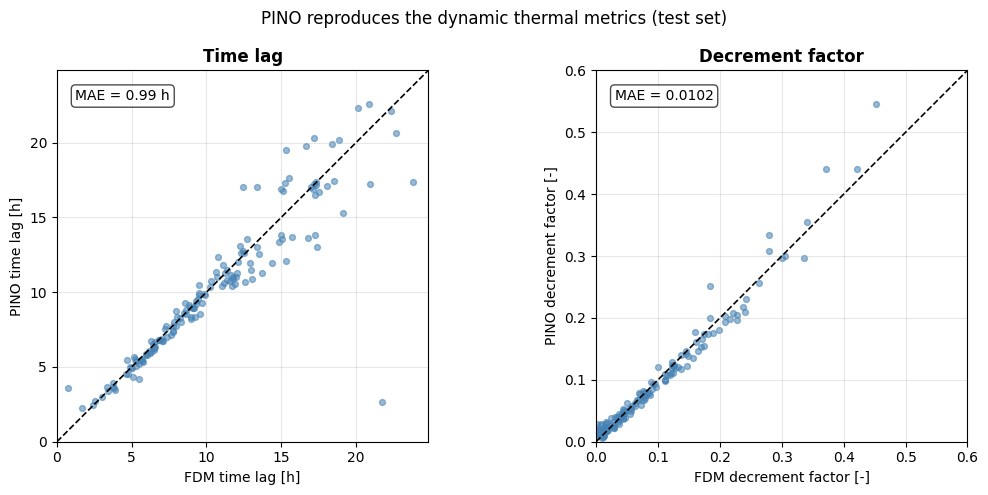

MAE time lag = 0.987 h | MAE decrement = 0.01018
Saved: pino_dynamic_metrics_parity.png


In [10]:
"""
================================================================
SECTION 8c — NEW FIGURE: dynamic-metrics parity (lag & decrement)
================================================================
Shows the surrogate reproduces the ISO-13786-style dynamic metrics
(time lag, decrement factor) — not just the scalar peak J. Both the
FDM reference and the PINO prediction are evaluated on the SAME
121-point saved grid (fair comparison), with parabolic sub-grid
peak refinement. Produces: pino_dynamic_metrics_parity.png
================================================================
"""
t_sec = (tau * T_END).astype(np.float64)          # (121,) final-day seconds

def peak_time(t, y):
    """Time of maximum with 3-point parabolic refinement."""
    i = int(np.argmax(y))
    if 0 < i < len(y) - 1:
        d = y[i-1] - 2*y[i] + y[i+1]
        if abs(d) > 1e-12:
            return t[i] + 0.5*(t[1]-t[0])*(y[i-1] - y[i+1]) / d
    return t[i]

def dynamic_metrics(TL_K, mu_i):
    """(time lag [h], decrement [-]) from an inner-surface series."""
    T_sa = sol_air_profile(t_sec, mu_i[6], mu_i[8])
    lag = (peak_time(t_sec, TL_K) - peak_time(t_sec, T_sa)) / 3600.0
    if lag < 0:
        lag += 24.0
    sw = T_sa.max() - T_sa.min()
    dec = (TL_K.max() - TL_K.min()) / sw if sw > 1e-12 else np.nan
    return lag, dec

lag_true, lag_pred, dec_true, dec_pred = [], [], [], []
model_pino.eval()
with torch.no_grad():
    for idx in range(len(test_ds)):
        xb_t, yb_t = test_ds[idx]
        mu_i   = test_ds.mu[idx]
        TL_t   = yb_t[0].numpy()[-1, :] * T_std + T_mean
        TL_p   = model_pino(xb_t.unsqueeze(0).to(device))[0, 0, -1, :].cpu().numpy() \
                 * T_std + T_mean
        lt, dt_ = dynamic_metrics(TL_t, mu_i); lp, dp = dynamic_metrics(TL_p, mu_i)
        lag_true.append(lt); lag_pred.append(lp)
        dec_true.append(dt_); dec_pred.append(dp)

lag_true, lag_pred = np.array(lag_true), np.array(lag_pred)
dec_true, dec_pred = np.array(dec_true), np.array(dec_pred)
mae_lag = np.nanmean(np.abs(lag_pred - lag_true))
mae_dec = np.nanmean(np.abs(dec_pred - dec_true))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ax = axes[0]
lims = [0, max(lag_true.max(), lag_pred.max()) + 1]
ax.scatter(lag_true, lag_pred, alpha=0.55, s=18, color='steelblue')
ax.plot(lims, lims, 'k--', lw=1.2)
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')
ax.set_xlabel('FDM time lag [h]'); ax.set_ylabel('PINO time lag [h]')
ax.set_title('Time lag', fontweight='bold'); ax.grid(alpha=0.3)
ax.text(0.05, 0.92, f'MAE = {mae_lag:.2f} h', transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax = axes[1]
lims = [0, max(np.nanmax(dec_true), np.nanmax(dec_pred)) * 1.1]
ax.scatter(dec_true, dec_pred, alpha=0.55, s=18, color='steelblue')
ax.plot(lims, lims, 'k--', lw=1.2)
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')
ax.set_xlabel('FDM decrement factor [-]'); ax.set_ylabel('PINO decrement factor [-]')
ax.set_title('Decrement factor', fontweight='bold'); ax.grid(alpha=0.3)
ax.text(0.05, 0.92, f'MAE = {mae_dec:.4f}', transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.suptitle('PINO reproduces the dynamic thermal metrics (test set)', fontsize=12)
plt.tight_layout()
plt.savefig('pino_dynamic_metrics_parity.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"MAE time lag = {mae_lag:.3f} h | MAE decrement = {mae_dec:.5f}")
print("Saved: pino_dynamic_metrics_parity.png")

In [11]:
# ================================================================
# SECTION 9 — Material ranking (Table tab:ranking) — v2
# FDM ground truth is LOADED from material_ranking_diurnal.csv
# (produced by fdm_solver_diurnal.ipynb) — no hard-coded numbers.
# Also reports the FDM dynamic metrics (time lag, decrement).
# ================================================================
import csv as _csv

def predict(k_dry, rho, cp, alpha_moist, L, w0, T_out, T_in, G_s):
    """PINO forward pass for one mu; returns (T_field [K], J_peak [C])."""
    mu_np = np.array([k_dry, rho, cp, alpha_moist, L, w0, T_out, T_in, G_s],
                     dtype=np.float32)
    mu_n  = (mu_np - mu_mean) / mu_std
    xi_grid  = np.broadcast_to(xi[:, None],        (N_x, N_t))
    tau_grid = np.broadcast_to(tau[None, :],        (N_x, N_t))
    mu_grid  = np.broadcast_to(mu_n[:, None, None], (9, N_x, N_t))
    x_in = np.concatenate([xi_grid[None], tau_grid[None], mu_grid],
                          axis=0).astype(np.float32)
    xb = torch.from_numpy(x_in).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_n = model_pino(xb)
    T_K = pred_n[0, 0].cpu().numpy() * T_std + T_mean
    return T_K, float(T_K[-1, :].max()) - 273.15

# --- load FDM ground truth produced by the FDM notebook ---
fdm_rank = {}
with open(DRIVE + 'material_ranking_diurnal.csv') as f:
    for row in _csv.DictReader(f):
        fdm_rank[row['material']] = dict(
            J=float(row['J_peak_C']), lag=float(row['time_lag_h']),
            dec=float(row['decrement']))
assert len(fdm_rank) == 5, \
    'material_ranking_diurnal.csv missing/incomplete — upload it to MyDrive'

MATERIAL_PROPS = {
    'Lime-stabilised bamboo panel': [0.25,  900, 1800, 0.003],
    'Clay-straw adobe':             [0.35, 1400, 1000, 0.004],
    'Mud brick (unfired)':          [0.45, 1600,  880, 0.005],
    'Lime-mud composite':           [0.55, 1500,  900, 0.004],
    'Fired clay brick':             [0.65, 1800,  840, 0.005],
}
AVAIL = {'Lime-stabilised bamboo panel': 'L', 'Clay-straw adobe': 'H',
         'Mud brick (unfired)': 'H', 'Lime-mud composite': 'M',
         'Fired clay brick': 'H'}
NOMINAL = dict(L=0.25, w0=0.0, T_out=45.0, T_in=35.0, G_s=700.0)

model_pino.eval()
rows = []
for name, (kd, rho, cp, am) in MATERIAL_PROPS.items():
    _, J_pino = predict(kd, rho, cp, am, **NOMINAL)
    r = fdm_rank[name]
    rows.append((name, r['J'], J_pino, abs(J_pino - r['J']),
                 r['lag'], r['dec'], AVAIL[name]))
rows.sort(key=lambda x: x[1])

print(f"{'Rank':<5}{'Material':<30}{'J_FDM(C)':>9}{'J_PINO(C)':>10}"
      f"{'Err(K)':>8}{'lag(h)':>8}{'decr':>8}{'Av':>4}")
print('-' * 82)
for rank, r in enumerate(rows, 1):
    print(f"{rank:<5}{r[0]:<30}{r[1]:>9.2f}{r[2]:>10.2f}"
          f"{r[3]:>8.3f}{r[4]:>8.2f}{r[5]:>8.4f}{r[6]:>4}")

rank_fdm  = [r[0] for r in rows]
rank_pino = [r[0] for r in sorted(rows, key=lambda x: x[2])]
print(f"\nRanking identical FDM vs PINO: {rank_fdm == rank_pino}")

print("\nLaTeX snippet for Table tab:ranking:\n")
for rank, r in enumerate(rows, 1):
    print(f"{rank} & {r[0]} & {r[1]:.2f} & {r[2]:.2f} & {r[3]:.3f} & "
          f"{r[4]:.1f} & {r[5]:.3f} & \\textbf{{{r[6]}}} \\\\")

Rank Material                       J_FDM(C) J_PINO(C)  Err(K)  lag(h)    decr  Av
----------------------------------------------------------------------------------
1    Lime-stabilised bamboo panel      36.37     37.08   0.708   13.43  0.0161   L
2    Clay-straw adobe                  37.07     37.41   0.340   10.07  0.0386   H
3    Mud brick (unfired)               37.69     37.92   0.228    8.80  0.0580   H
4    Lime-mud composite                38.36     38.39   0.031    7.69  0.0815   M
5    Fired clay brick                  38.76     38.70   0.055    7.63  0.0903   H

Ranking identical FDM vs PINO: True

LaTeX snippet for Table tab:ranking:

1 & Lime-stabilised bamboo panel & 36.37 & 37.08 & 0.708 & 13.4 & 0.016 & \textbf{L} \\
2 & Clay-straw adobe & 37.07 & 37.41 & 0.340 & 10.1 & 0.039 & \textbf{H} \\
3 & Mud brick (unfired) & 37.69 & 37.92 & 0.228 & 8.8 & 0.058 & \textbf{H} \\
4 & Lime-mud composite & 38.36 & 38.39 & 0.031 & 7.7 & 0.082 & \textbf{M} \\
5 & Fired clay brick & 3

In [12]:
# ================================================================
# SECTION 10 — Cost-performance assessment (Table tab:cost) — v2
# J values come from the loaded fdm_rank dict (no hard-coding).
# ================================================================
L_ref = 0.25
material_names = list(MATERIAL_PROPS.keys())
k_dry_arr = np.array([MATERIAL_PROPS[m][0] for m in material_names])
# Indicative 2025-2026 market costs (PKR/m^3, rural Sindh) —
# authors' estimates; verify with local supplier records before final reporting
C_MAT = {'Clay-straw adobe': 3500, 'Mud brick (unfired)': 4500,
         'Lime-mud composite': 8000, 'Lime-stabilised bamboo panel': 20000,
         'Fired clay brick': 10500}
C_mat  = np.array([C_MAT[m] for m in material_names], float)
C_area = C_mat * L_ref
J_arr  = np.array([fdm_rank[m]['J'] for m in material_names])
R      = L_ref / k_dry_arr

CPI_static = (R / C_area);            CPI_static /= CPI_static.max()
J_max      = J_arr.max()
CPI_dyn    = (J_max - J_arr) / C_area
CPI_dyn   /= CPI_dyn.max()

print(f"Reference thickness L_ref = {L_ref} m | "
      f"J_max = {J_max:.2f} C ({material_names[int(np.argmax(J_arr))]})\n")
hdr = (f"{'Material':<30}{'C_mat':>8}{'PKR/m2':>8}{'R_i':>7}"
       f"{'CPI_s':>7}{'CPI_d':>7}{'Av':>4}")
print(hdr); print('-' * 71)
for i in np.argsort(-CPI_static):
    m = material_names[i]
    print(f"{m:<30}{C_mat[i]:>8,.0f}{C_area[i]:>8,.0f}{R[i]:>7.2f}"
          f"{CPI_static[i]:>7.3f}{CPI_dyn[i]:>7.3f}{AVAIL[m]:>4}")

print("\nLaTeX snippet for Table tab:cost:\n")
for i in np.argsort(-CPI_static):
    m = material_names[i]
    print(f"{m} & {C_mat[i]:,.0f} & {C_area[i]:,.0f} & {R[i]:.2f} & "
          f"{CPI_static[i]:.2f} & {CPI_dyn[i]:.3f} & \\textbf{{{AVAIL[m]}}} \\\\")

Reference thickness L_ref = 0.25 m | J_max = 38.76 C (Fired clay brick)

Material                         C_mat  PKR/m2    R_i  CPI_s  CPI_d  Av
-----------------------------------------------------------------------
Clay-straw adobe                 3,500     875   0.71  1.000  1.000   H
Mud brick (unfired)              4,500   1,125   0.56  0.605  0.490   H
Lime-mud composite               8,000   2,000   0.45  0.278  0.104   M
Lime-stabilised bamboo panel    20,000   5,000   1.00  0.245  0.248   L
Fired clay brick                10,500   2,625   0.38  0.179  0.000   H

LaTeX snippet for Table tab:cost:

Clay-straw adobe & 3,500 & 875 & 0.71 & 1.00 & 1.000 & \textbf{H} \\
Mud brick (unfired) & 4,500 & 1,125 & 0.56 & 0.60 & 0.490 & \textbf{H} \\
Lime-mud composite & 8,000 & 2,000 & 0.45 & 0.28 & 0.104 & \textbf{M} \\
Lime-stabilised bamboo panel & 20,000 & 5,000 & 1.00 & 0.24 & 0.248 & \textbf{L} \\
Fired clay brick & 10,500 & 2,625 & 0.38 & 0.18 & 0.000 & \textbf{H} \\


Swept: Lime-stabilised bamboo panel (400 points)
Swept: Clay-straw adobe (400 points)
Swept: Mud brick (unfired) (400 points)
Swept: Lime-mud composite (400 points)
Swept: Fired clay brick (400 points)

Total PINO evaluations: 2000


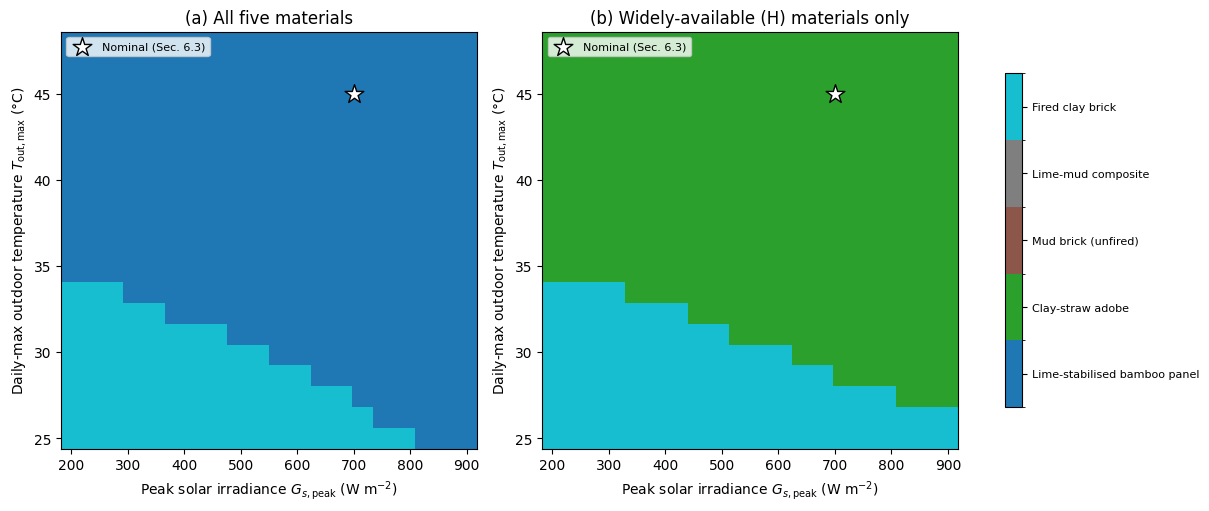

Saved: /content/drive/MyDrive/climate_heatmap.pdf
Saved CSV to /content/drive/MyDrive/climate_sweep_results.csv

--- Win share across full grid (all 5 materials) ---
Lime-stabilised bamboo panel      79.00%
Clay-straw adobe                   0.00%
Mud brick (unfired)                0.00%
Lime-mud composite                 0.00%
Fired clay brick                  21.00%

--- Win share across full grid (H-availability only) ---
Clay-straw adobe                  74.25%
Mud brick (unfired)                0.00%
Fired clay brick                  25.75%

--- FDM spot-check points (solve these manually per material) ---
T_out=25.0 C, G_s=200.0 W/m^2
T_out=25.0 C, G_s=550.0 W/m^2
T_out=25.0 C, G_s=900.0 W/m^2
T_out=36.5 C, G_s=200.0 W/m^2
T_out=36.5 C, G_s=550.0 W/m^2
T_out=36.5 C, G_s=900.0 W/m^2
T_out=48.0 C, G_s=200.0 W/m^2
T_out=48.0 C, G_s=550.0 W/m^2
T_out=48.0 C, G_s=900.0 W/m^2


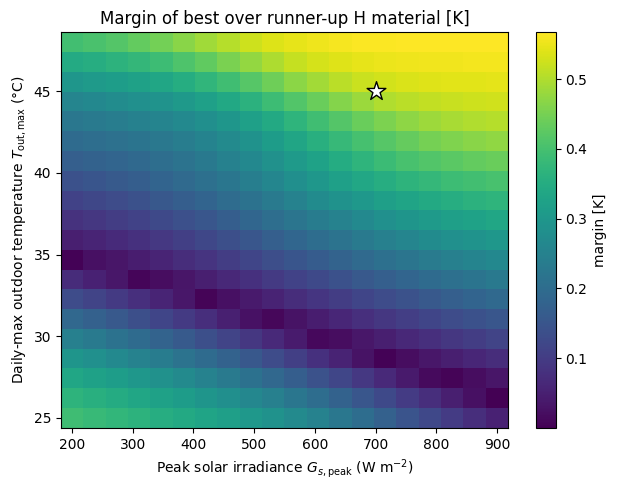

Margin over grid: min=0.00 K, median=0.24 K, max=0.57 K
Saved: climate_margin_map.pdf


In [13]:
# ================================================================
# SECTION 11 — Climate sweep heatmap (generalization analysis)
# Sweeps (T_out_max, G_s_peak) over the Table 1 ranges, holding T_in=35C,
# w0=0, L=0.25m fixed, for all 5 materials. Uses the SAME predict()
# function and normalization stats defined in Sections 1 and 9 --
# run this AFTER Section 6 (checkpoint loading) and Section 9
# (material ranking / predict() definition). No retraining.
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import csv

# ----------------------------------------------------------------
# Config -- matches Table 1 ranges in the manuscript
# ----------------------------------------------------------------
N_TOUT = 20
N_GS   = 20

TOUT_RANGE = (25.0, 48.0)   # deg C
GS_RANGE   = (200.0, 900.0) # W/m^2

TIN_NOMINAL = 35.0
W0_NOMINAL  = 0.0
L_NOMINAL   = 0.25

NOMINAL_TOUT = 45.0
NOMINAL_GS   = 700.0

# Same 5 materials/params as Section 9 (name, [kdry, rho, cp, alpha])
MATERIALS = [
    ("Lime-stabilised bamboo panel", [0.25,  900, 1800, 0.003], "L"),
    ("Clay-straw adobe",             [0.35, 1400, 1000, 0.004], "H"),
    ("Mud brick (unfired)",          [0.45, 1600,  880, 0.005], "H"),
    ("Lime-mud composite",           [0.55, 1500,  900, 0.004], "M"),
    ("Fired clay brick",             [0.65, 1800,  840, 0.005], "H"),
]
MATERIAL_NAMES = [m[0] for m in MATERIALS]
H_INDICES = [i for i, m in enumerate(MATERIALS) if m[2] == "H"]

# ----------------------------------------------------------------
# Run the sweep -- reuses predict() from Section 9 as-is
# ----------------------------------------------------------------
tout_grid = np.linspace(*TOUT_RANGE, N_TOUT)
gs_grid   = np.linspace(*GS_RANGE, N_GS)

J_all = np.zeros((len(MATERIALS), N_TOUT, N_GS))  # [material, i_tout, j_gs]

model_pino.eval()
for mi, (name, props, avail) in enumerate(MATERIALS):
    kdry, rho, cp, alpha = props
    for i, Tout in enumerate(tout_grid):
        for j, Gs in enumerate(gs_grid):
            _, J_C = predict(
                k_dry=kdry, rho=rho, cp=cp, alpha_moist=alpha,
                L=L_NOMINAL, w0=W0_NOMINAL,
                T_out=Tout, T_in=TIN_NOMINAL, G_s=Gs,
            )
            J_all[mi, i, j] = J_C
    print(f"Swept: {name} ({N_TOUT * N_GS} points)")

print(f"\nTotal PINO evaluations: {len(MATERIALS) * N_TOUT * N_GS}")

# ----------------------------------------------------------------
# Determine winning material at each grid point
# ----------------------------------------------------------------
def winner_grid(J_all, subset_idx):
    sub = J_all[subset_idx, :, :]
    winner_local = np.argmin(sub, axis=0)
    return np.array(subset_idx)[winner_local]

winner_all = winner_grid(J_all, list(range(len(MATERIALS))))
winner_H   = winner_grid(J_all, H_INDICES)

# ----------------------------------------------------------------
# Plot two-panel heatmap
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

cmap = plt.get_cmap("tab10", len(MATERIALS))
bounds = np.arange(-0.5, len(MATERIALS) + 0.5, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

for ax, winner, title in zip(
    axes, [winner_all, winner_H],
    ["(a) All five materials", "(b) Widely-available (H) materials only"]
):
    im = ax.pcolormesh(gs_grid, tout_grid, winner, cmap=cmap, norm=norm, shading="auto")
    ax.set_xlabel(r"Peak solar irradiance $G_{s,\mathrm{peak}}$ (W m$^{-2}$)")
    ax.set_ylabel(r"Daily-max outdoor temperature $T_{\mathrm{out,max}}$ (°C)")
    ax.set_title(title)
    ax.scatter([NOMINAL_GS], [NOMINAL_TOUT], marker="*", s=200,
               c="white", edgecolors="black", zorder=5, label="Nominal (Sec. 6.3)")
    ax.legend(loc="upper left", fontsize=8)

cbar = fig.colorbar(im, ax=axes, ticks=range(len(MATERIALS)), shrink=0.8)
cbar.ax.set_yticklabels(MATERIAL_NAMES, fontsize=8)

fig.savefig(DRIVE + 'climate_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", DRIVE + "climate_heatmap.pdf")

# ----------------------------------------------------------------
# Save CSV summary
# ----------------------------------------------------------------
csv_path = DRIVE + 'climate_sweep_results.csv'
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Tout_C", "Gs_Wm2", "winner_all5", "winner_H_only"])
    for i, Tout in enumerate(tout_grid):
        for j, Gs in enumerate(gs_grid):
            writer.writerow([Tout, Gs, MATERIAL_NAMES[winner_all[i, j]], MATERIAL_NAMES[winner_H[i, j]]])
print(f"Saved CSV to {csv_path}")

# ----------------------------------------------------------------
# Summary stats: how much of the grid does each material win?
# ----------------------------------------------------------------
print("\n--- Win share across full grid (all 5 materials) ---")
for mi, name in enumerate(MATERIAL_NAMES):
    share = 100.0 * np.mean(winner_all == mi)
    print(f"{name:<32s} {share:6.2f}%")

print("\n--- Win share across full grid (H-availability only) ---")
for mi in H_INDICES:
    name = MATERIAL_NAMES[mi]
    share = 100.0 * np.mean(winner_H == mi)
    print(f"{name:<32s} {share:6.2f}%")

# ----------------------------------------------------------------
# FDM spot-check helper: prints the grid points to solve manually
# with your FDM solver (corners, edge midpoints, centre = 9 points)
# ----------------------------------------------------------------
print("\n--- FDM spot-check points (solve these manually per material) ---")
spot_tout = [TOUT_RANGE[0], (TOUT_RANGE[0]+TOUT_RANGE[1])/2, TOUT_RANGE[1]]
spot_gs   = [GS_RANGE[0], (GS_RANGE[0]+GS_RANGE[1])/2, GS_RANGE[1]]
for Tout in spot_tout:
    for Gs in spot_gs:
        print(f"T_out={Tout:.1f} C, G_s={Gs:.1f} W/m^2")

# ----------------------------------------------------------------
# NEW: recommendation-robustness (margin) map — how much better is
# the best H material than the runner-up H material, in kelvin?
# Larger margin = more robust recommendation. Complements the
# winner map, which shows WHO wins but not BY HOW MUCH.
# ----------------------------------------------------------------
sub_H   = J_all[H_INDICES, :, :]
sorted_H = np.sort(sub_H, axis=0)
margin_H = sorted_H[1] - sorted_H[0]           # (N_TOUT, N_GS), in K

fig, ax = plt.subplots(figsize=(6.4, 5))
im = ax.pcolormesh(gs_grid, tout_grid, margin_H, cmap="viridis", shading="auto")
ax.set_xlabel(r"Peak solar irradiance $G_{s,\mathrm{peak}}$ (W m$^{-2}$)")
ax.set_ylabel(r"Daily-max outdoor temperature $T_{\mathrm{out,max}}$ (°C)")
ax.set_title("Margin of best over runner-up H material [K]")
ax.scatter([NOMINAL_GS], [NOMINAL_TOUT], marker="*", s=200, c="white",
           edgecolors="black", zorder=5)
fig.colorbar(im, ax=ax, label="margin [K]")
plt.tight_layout()
fig.savefig(DRIVE + 'climate_margin_map.pdf', dpi=300, bbox_inches='tight')
plt.show()
print(f"Margin over grid: min={margin_H.min():.2f} K, "
      f"median={np.median(margin_H):.2f} K, max={margin_H.max():.2f} K")
print("Saved: climate_margin_map.pdf")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 44.4 MB/s eta 0:00:00


/tmp/ipykernel_854/782703433.py:49: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N_BASE, calc_second_order=False)


Total PINO evaluations required: 11264
  2000/11264 evaluations done
  4000/11264 evaluations done
  6000/11264 evaluations done
  8000/11264 evaluations done
  10000/11264 evaluations done
Finished 11264 PINO evaluations.
J range: 24.74 - 52.45 C

SOBOL SENSITIVITY INDICES (sorted by S_T, descending)
Rank  Parameter               S1    S1_conf         ST    ST_conf
----------------------------------------------------------------------
1     T_in                0.7371     0.0707     0.7603     0.0615
2     T_out_max           0.1339     0.0352     0.1521     0.0177
3     L                   0.0310     0.0192     0.0490     0.0090
4     k_dry               0.0111     0.0168     0.0336     0.0058
5     G_s_peak            0.0259     0.0144     0.0298     0.0045
6     cp                  0.0095     0.0081     0.0114     0.0020
7     rho                 0.0065     0.0083     0.0088     0.0015
8     w0                  0.0001     0.0022     0.0006     0.0001
9     alpha_moist        -0.0035

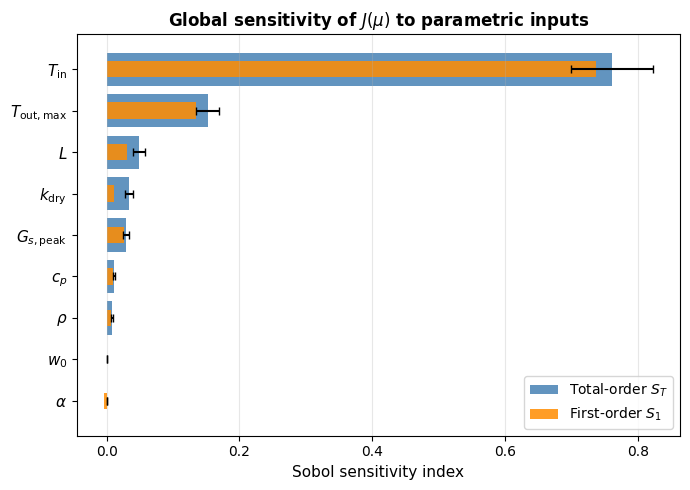


Saved: /content/drive/MyDrive/sobol_indices.pdf
Saved CSV to /content/drive/MyDrive/sobol_results.csv


In [14]:
# ================================================================
# SECTION 12 — Global Sensitivity Analysis (Sobol indices)
# Uses the trained PINO (model_pino) as a cheap surrogate to
# estimate first-order (S1) and total-order (ST) Sobol indices
# for all 9 parameters in mu, with respect to the QoI
# J(mu) = peak inner surface temperature.
#
# Run this AFTER Section 6 (checkpoint loading) and Section 9
# (predict() definition) -- reuses predict() and normalization
# stats as-is. No retraining.
# ================================================================

# Install SALib (one-time, safe to re-run)
!pip install -q SALib

import numpy as np
from SALib.sample import saltelli
from SALib.analyze import sobol

# ----------------------------------------------------------------
# Problem definition -- ranges match Table 1 / eq:params exactly
# Order: k_dry, rho, cp, alpha_moist, L, w0, T_out, T_in, G_s
# ----------------------------------------------------------------
problem = {
    'num_vars': 9,
    'names': ['k_dry', 'rho', 'cp', 'alpha_moist', 'L', 'w0', 'T_out_max', 'T_in', 'G_s_peak'],
    'bounds': [
        [0.20,   1.50],    # k_dry        W/m/K
        [800,    2200],    # rho          kg/m^3
        [650,    2000],    # cp           J/kg/K
        [0.001,  0.010],   # alpha_moist  W m^2/kg/K
        [0.15,   0.45],    # L            m
        [0,      30],      # w0           kg/m^3
        [25,     48],      # T_out        deg C
        [25,     45],      # T_in         deg C
        [200,    900],     # G_s          W/m^2
    ]
}

# ----------------------------------------------------------------
# Saltelli sampling
# N=1024 base samples -> N*(D+2) = 1024*11 = 11264 evaluations
# (first-order + total-order only; calc_second_order=False)
# All done via the trained PINO (milliseconds each) -- no FDM,
# no retraining. Increase N if you want tighter confidence
# intervals; 1024 is a reasonable default for a 9D problem.
# ----------------------------------------------------------------
N_BASE = 1024
param_values = saltelli.sample(problem, N_BASE, calc_second_order=False)
print(f"Total PINO evaluations required: {param_values.shape[0]}")

# ----------------------------------------------------------------
# Evaluate J(mu) via the trained PINO for every sampled mu
# ----------------------------------------------------------------
model_pino.eval()
J_samples = np.zeros(param_values.shape[0])

for i, row in enumerate(param_values):
    k_dry, rho, cp, alpha_moist, L, w0, T_out, T_in, G_s = row
    _, J_C = predict(
        k_dry=k_dry, rho=rho, cp=cp, alpha_moist=alpha_moist,
        L=L, w0=w0, T_out=T_out, T_in=T_in, G_s=G_s
    )
    J_samples[i] = J_C

    if (i + 1) % 2000 == 0:
        print(f"  {i + 1}/{param_values.shape[0]} evaluations done")

print(f"Finished {param_values.shape[0]} PINO evaluations.")
print(f"J range: {J_samples.min():.2f} - {J_samples.max():.2f} C")

# ----------------------------------------------------------------
# Sobol analysis
# ----------------------------------------------------------------
Si = sobol.analyze(problem, J_samples, calc_second_order=False, print_to_console=False)

# ----------------------------------------------------------------
# Print results sorted by total-order index (descending)
# ----------------------------------------------------------------
names = problem['names']
S1  = Si['S1']
S1_conf = Si['S1_conf']
ST  = Si['ST']
ST_conf = Si['ST_conf']

order = np.argsort(-ST)  # descending by total-order

print("\n" + "="*70)
print("SOBOL SENSITIVITY INDICES (sorted by S_T, descending)")
print("="*70)
print(f"{'Rank':<5} {'Parameter':<15} {'S1':>10} {'S1_conf':>10} {'ST':>10} {'ST_conf':>10}")
print("-"*70)
for rank, idx in enumerate(order, 1):
    print(f"{rank:<5} {names[idx]:<15} {S1[idx]:>10.4f} {S1_conf[idx]:>10.4f} "
          f"{ST[idx]:>10.4f} {ST_conf[idx]:>10.4f}")

# ----------------------------------------------------------------
# LaTeX table snippet (sorted, matching tab:sobol format)
# ----------------------------------------------------------------
LATEX_NAME_MAP = {
    'k_dry':       r'$k_{\mathrm{dry}}$',
    'rho':         r'$\rho$',
    'cp':          r'$c_p$',
    'alpha_moist': r'$\alpha$',
    'L':           r'$L$',
    'w0':          r'$w_0$',
    'T_out_max':   r'$T_{\mathrm{out,max}}$',
    'T_in':        r'$T_{\mathrm{in}}$',
    'G_s_peak':    r'$G_{s,\mathrm{peak}}$',
}

print("\nLaTeX snippet for Table tab:sobol:\n")
for rank, idx in enumerate(order, 1):
    latex_name = LATEX_NAME_MAP[names[idx]]
    print(f"{rank} & {latex_name} & {S1[idx]:.3f} $\\pm$ {S1_conf[idx]:.3f} & "
          f"{ST[idx]:.3f} $\\pm$ {ST_conf[idx]:.3f} \\\\")

# ----------------------------------------------------------------
# Tornado plot (horizontal bar chart, sorted by ST)
# ----------------------------------------------------------------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

sorted_names = [LATEX_NAME_MAP[names[idx]] for idx in order]
sorted_ST    = ST[order]
sorted_ST_conf = ST_conf[order]
sorted_S1    = S1[order]

y_pos = np.arange(len(sorted_names))

ax.barh(y_pos, sorted_ST, xerr=sorted_ST_conf, align='center',
        color='steelblue', alpha=0.85, label=r'Total-order $S_T$', capsize=3)
ax.barh(y_pos, sorted_S1, align='center',
        color='darkorange', alpha=0.85, height=0.4, label=r'First-order $S_1$')

ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_names, fontsize=11)
ax.invert_yaxis()  # highest sensitivity at top
ax.set_xlabel('Sobol sensitivity index', fontsize=11)
ax.set_title('Global sensitivity of $J(\\mu)$ to parametric inputs', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(DRIVE + 'sobol_indices.pdf', dpi=300, bbox_inches='tight')
plt.savefig('sobol_indices.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved:", DRIVE + "sobol_indices.pdf")

# ----------------------------------------------------------------
# Save raw results to CSV for your records
# ----------------------------------------------------------------
import csv
csv_path = DRIVE + 'sobol_results.csv'
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['rank', 'parameter', 'S1', 'S1_conf', 'ST', 'ST_conf'])
    for rank, idx in enumerate(order, 1):
        writer.writerow([rank, names[idx], S1[idx], S1_conf[idx], ST[idx], ST_conf[idx]])
print(f"Saved CSV to {csv_path}")

[FNO-N150] epoch   0  train=1.0143e+00 (data=1.0143e+00, pde=0.0000e+00)  val=1.0000e+00  best_val=1.0000e+00
[FNO-N150] epoch   5  train=7.3230e-01 (data=7.3230e-01, pde=0.0000e+00)  val=9.8071e-01  best_val=9.8071e-01
[FNO-N150] epoch  10  train=3.7081e-01 (data=3.7081e-01, pde=0.0000e+00)  val=7.1691e-01  best_val=7.1691e-01
[FNO-N150] epoch  15  train=2.3949e-01 (data=2.3949e-01, pde=0.0000e+00)  val=2.9571e-01  best_val=2.9571e-01
[FNO-N150] epoch  20  train=2.0146e-01 (data=2.0146e-01, pde=0.0000e+00)  val=1.8287e-01  best_val=1.8287e-01
[FNO-N150] epoch  25  train=1.3023e-01 (data=1.3023e-01, pde=0.0000e+00)  val=1.5604e-01  best_val=1.5003e-01
[FNO-N150] epoch  30  train=1.1937e-01 (data=1.1937e-01, pde=0.0000e+00)  val=1.2752e-01  best_val=1.2752e-01
[FNO-N150] epoch  35  train=1.3076e-01 (data=1.3076e-01, pde=0.0000e+00)  val=1.2925e-01  best_val=1.1863e-01
[FNO-N150] epoch  40  train=1.5847e-01 (data=1.5847e-01, pde=0.0000e+00)  val=1.2323e-01  best_val=1.1822e-01
[FNO-N150]

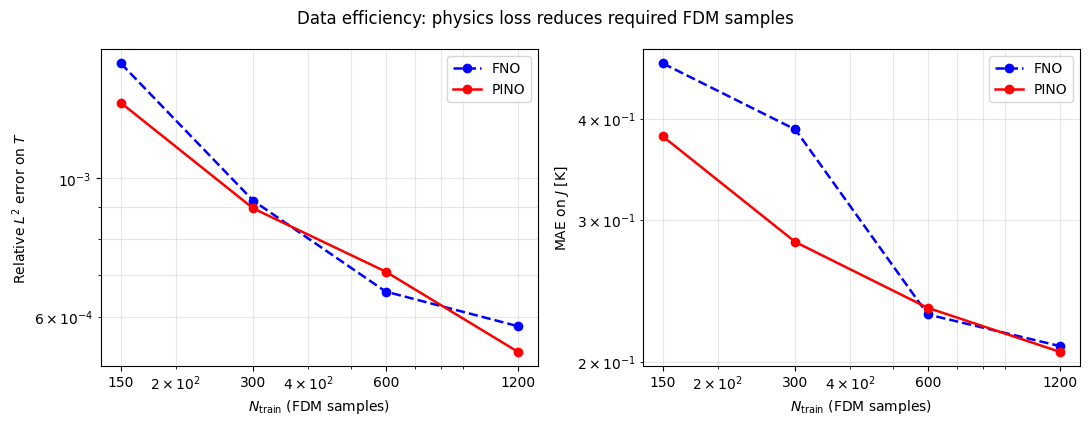

Saved: data_efficiency.png, data_efficiency.csv


In [15]:
# ================================================================
# SECTION 13 — OPTIONAL: data-efficiency study (STRONGLY RECOMMENDED
# for the manuscript; set RUN_DATA_EFFICIENCY = False to skip)
# ================================================================
# Trains FNO and PINO at nested training-set sizes and plots test
# error vs. N_train. This demonstrates the claim that the PDE loss
# reduces the number of FDM samples required — currently asserted in
# the manuscript but not shown. RUNTIME: roughly 1-2 h on a T4 GPU
# (8 trainings, capped at 200 epochs each).
# Produces: data_efficiency.png, data_efficiency.csv
# ================================================================
RUN_DATA_EFFICIENCY = True

if RUN_DATA_EFFICIENCY:
    import csv as _csv2
    SIZES = [150, 300, 600, 1200]
    eff_results = []

    for n_sub in SIZES:
        sub_idx = idx_train[:n_sub]      # nested subsets of the SAME split
        ds_sub = SindhDataset(mu_raw[sub_idx], T_field[sub_idx], xi, tau,
                              **norm_stats)
        loader_sub = DataLoader(ds_sub, batch_size=BATCH_SIZE,
                                shuffle=True, drop_last=True)
        for use_pde, tag in [(False, 'FNO'), (True, 'PINO')]:
            torch.manual_seed(42); np.random.seed(42)
            m = FNO2d(in_channels=11, out_channels=1, width=32,
                      modes_x=16, modes_t=20, n_layers=4).to(device)
            m, _ = train_model(m, loader_sub, val_loader,
                               use_pde_loss=use_pde, n_epochs=200,
                               lr=1e-3, lambda_pde=0.01, patience=20,
                               tag=f'{tag}-N{n_sub}')
            rel, maeJ, *_ = evaluate_model(m, test_loader, T_mean, T_std)
            eff_results.append((n_sub, tag, rel, maeJ))
            print(f'  -> N_train={n_sub:5d} {tag:5s} '
                  f'relL2={rel:.3e}  MAE_J={maeJ:.3f} K')

    with open('data_efficiency.csv', 'w', newline='') as f:
        w = _csv2.writer(f)
        w.writerow(['N_train', 'model', 'rel_L2_T', 'MAE_J_K'])
        w.writerows(eff_results)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
    for tag, color, ls in [('FNO', 'b', '--'), ('PINO', 'r', '-')]:
        n  = [r[0] for r in eff_results if r[1] == tag]
        rl = [r[2] for r in eff_results if r[1] == tag]
        mj = [r[3] for r in eff_results if r[1] == tag]
        axes[0].loglog(n, rl, color + ls + 'o', label=tag, lw=1.8)
        axes[1].loglog(n, mj, color + ls + 'o', label=tag, lw=1.8)
    axes[0].set_ylabel(r'Relative $L^2$ error on $T$')
    axes[1].set_ylabel(r'MAE on $J$ [K]')
    for ax in axes:
        ax.set_xlabel(r'$N_{\mathrm{train}}$ (FDM samples)')
        ax.set_xticks(SIZES); ax.set_xticklabels(SIZES)
        ax.legend(); ax.grid(alpha=0.3, which='both')
    plt.suptitle('Data efficiency: physics loss reduces required FDM samples',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig('data_efficiency.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: data_efficiency.png, data_efficiency.csv')
else:
    print('Data-efficiency study skipped (RUN_DATA_EFFICIENCY = False).')

## Figure → manuscript mapping (recommended)

**Main text (replaces/updates v1 figures):**
1. `diurnal_forcing.png` *(from the FDM notebook)* — new Fig. introducing the forcing model.
2. `pino_field_comparison.png` — Fig. 1 (state the sample is the median-error test sample).
3. `pino_qoi_comparison.png` — Fig. 2 (now with sol-air context).
4. `pino_parity_J.png` — Fig. 3.
5. `pino_training_curves.png` — Fig. 4.
6. **NEW** `pino_error_vs_position.png` — turns the "PDE loss helps near the inner surface" sentence into evidence.
7. **NEW** `pino_dynamic_metrics_parity.png` — headline addition: the surrogate predicts ISO-13786-style lag and decrement, which now also appear in the ranking table.
8. `climate_heatmap.pdf` + **NEW** `climate_margin_map.pdf` — winner map plus how robust the winner is (reviewers like margins, not just argmins).
9. **NEW** `data_efficiency.png` (optional cell, ~1–2 h) — the single most persuasive ML figure: shows the physics loss reduces required FDM samples. If short on time set `RUN_DATA_EFFICIENCY = False` and keep the claim out of the paper.

**Appendix/supplementary:** `pino_qoi_worst_case.png` (transparency), `sobol_indices.pdf` (now with confidence intervals in the LaTeX snippet), `transient_sanity_diurnal.png` (from the FDM notebook).

**Tables:** ranking table now has columns J_FDM, J_PINO, |err|, time lag, decrement, availability — LaTeX snippets are printed by the ranking, cost, and Sobol cells.